In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [8]:
data = pd.read_csv("an_age_data_clean.csv")
data

,HAGRID,Species,Name,Longevity,Kingdom,Phylum,Class,Order,Family,Genus,...,Clutch size,Clutches per year,Weight at hatching,IMR,MRDT,Metamorphosis,Resting metabolic rate,Interbirth interval,Clutch or litter size,Breedings per year
0,3242,Orycteropus afer,Aardvark,29.8,Animalia,Chordata,Mammalia (Taxon entry),Tubulidentata,Orycteropodidae,Orycteropus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2161,Proteles cristata,Aardwolf,20,Animalia,Chordata,Mammalia (Taxon entry),Carnivora,Hyaenidae,Proteles,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3296,Chilabothrus exsul,Abaco Island boa,21.7,Animalia,Chordata,Reptilia (Taxon entry),Squamata,Boidae,Chilabothrus,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,570,Ciconia abdimii,Abdim's stork,21.6,Animalia,Chordata,Aves (Taxon entry),Ciconiiformes,Ciconiidae,Ciconia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1896,Addax nasomaculatus,Addax,28,Animalia,Chordata,Mammalia (Taxon entry),Artiodactyla,Bovidae,Addax,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3963,4315,Sander lucioperca,Zander,16,Animalia,Chordata,Teleostei,Perciformes,Percidae,Sander,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3964,3900,Danio rerio,Zebra danio or zebrafish,5.5,Animalia,Chordata,Teleostei,Cypriniformes,Cyprinidae,Danio,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3965,597,Geopelia striata,Zebra dove,18.7,Animalia,Chordata,Aves (Taxon entry),Columbiformes,Columbidae,Geopelia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3966,882,Taeniopygia guttata,Zebra finch,12,Animalia,Chordata,Aves (Taxon entry),Passeriformes,Estrildidae,Taeniopygia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Processing


In [11]:
# data = data.convert_dtypes()
data[data["Longevity"] == "--"] = np.nan
data["Longevity"] = data["Longevity"].astype(float)

<Axes: xlabel='Longevity', ylabel='Density'>

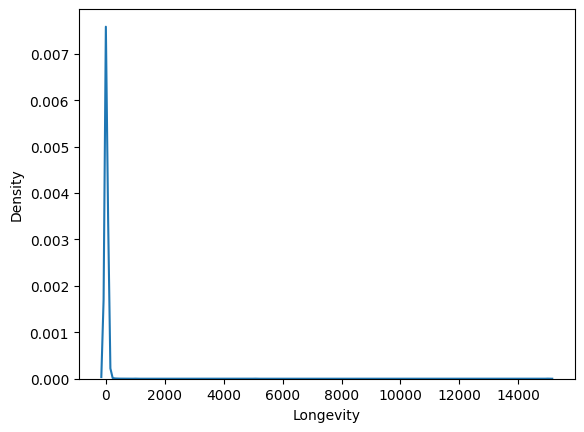

In [ ]:
sns.kdeplot(data["Longevity"])

Due to skewed distribution, use logarithms of target column


<Axes: xlabel='Longevity_log', ylabel='Density'>

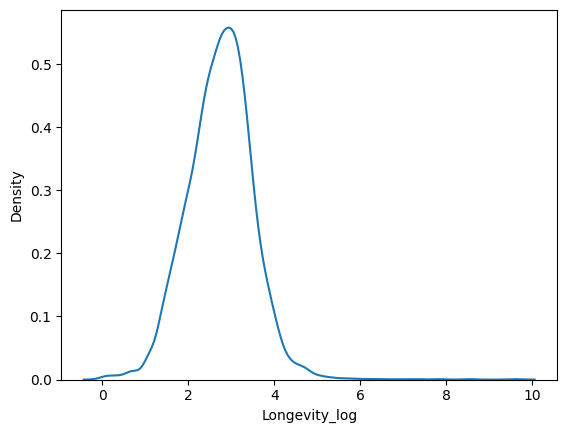

In [13]:
data["Longevity_log"] = np.log1p(data["Longevity"])
sns.kdeplot(data["Longevity_log"])

# Training


In [ ]:
train_data = data.drop(columns=["HAGRID", "Species", "Name"]).dropna(how="all")

cat_features = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus"]
target_col = "Longevity_log"

X = train_data.drop(columns=["Longevity", "Longevity_log"])
y = train_data[target_col]

# X[cat_features].fillna("NA", inplace=True)

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=17)

train_pool = Pool(X_train, y_train, cat_features)
valid_pool = Pool(X_valid, y_valid, cat_features)

In [ ]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=1e-2,
    loss_function="MAE",
    depth=4,
    border_count=255,
    random_seed=17,
)
model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    verbose=100,
    early_stopping_rounds=300,
)

0:	learn: 0.5802200	test: 0.5799573	best: 0.5799573 (0)	total: 58ms	remaining: 57.9s
100:	learn: 0.4491636	test: 0.4341020	best: 0.4341020 (100)	total: 346ms	remaining: 3.08s
200:	learn: 0.4041130	test: 0.3846141	best: 0.3846141 (200)	total: 533ms	remaining: 2.12s
300:	learn: 0.3823000	test: 0.3604447	best: 0.3604447 (300)	total: 882ms	remaining: 2.05s
400:	learn: 0.3712624	test: 0.3514917	best: 0.3514917 (400)	total: 1.25s	remaining: 1.87s
500:	learn: 0.3643078	test: 0.3464811	best: 0.3464811 (500)	total: 1.67s	remaining: 1.66s
600:	learn: 0.3594033	test: 0.3432784	best: 0.3432784 (600)	total: 1.81s	remaining: 1.21s
700:	learn: 0.3553718	test: 0.3413982	best: 0.3413788 (699)	total: 2.08s	remaining: 889ms
800:	learn: 0.3513996	test: 0.3396607	best: 0.3396607 (800)	total: 2.47s	remaining: 614ms
900:	learn: 0.3479292	test: 0.3384870	best: 0.3384870 (900)	total: 2.91s	remaining: 320ms
999:	learn: 0.3448723	test: 0.3373961	best: 0.3373961 (999)	total: 3.13s	remaining: 0us

bestTest = 0.337

## Testing on validation set


In [ ]:
log_preds = model.predict(X_valid)
valid_preds = np.exp(log_preds)

valid_df = train_data.loc[X_valid.index]

mae = mean_absolute_error(valid_df["Longevity"], valid_preds)

print(f"Mean Abs Error: {mae}")

Mean Abs Error: 6.7515873313482775


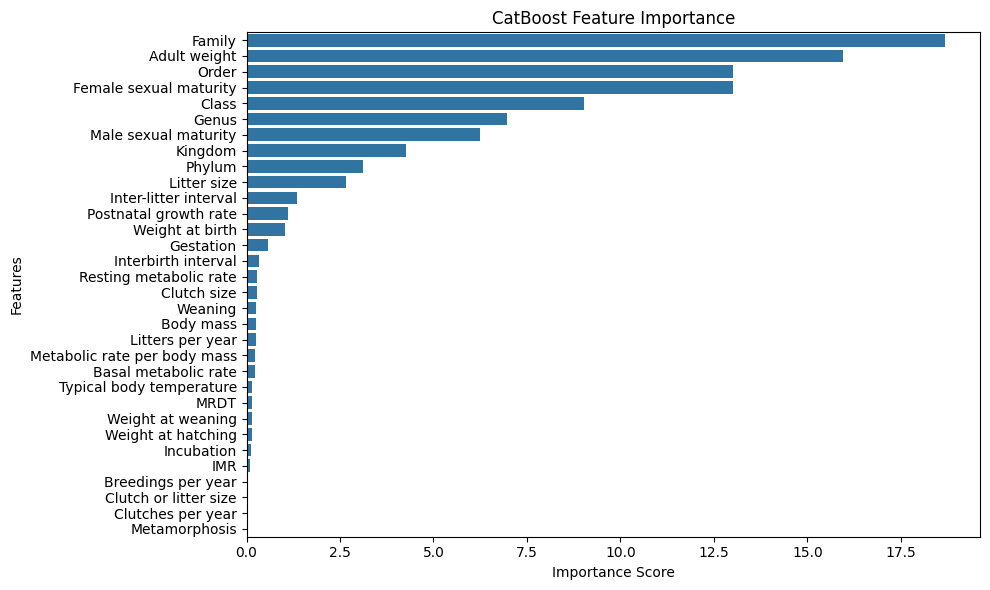

In [ ]:
importance = model.get_feature_importance()
feature_names = X_train.columns

feature_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": importance}
).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feature_df)

plt.title("CatBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()